In [4]:
from lagp.utils.generate_data import pdf_asym_laplace, load_data, compute_dict_pars, quantile_func_asym_laplace
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.stats import norm
from scipy.optimize import minimize
import yaml
import gpboost as gpb
import gpytorch as gpy  
import torch
from scipy.stats import multivariate_normal
#plt.style.use('ggplot')
from ipywidgets import interact, widgets, interactive
from scipy.stats import t as t_dist
from scipy.stats import nct
import pickle

In [9]:
# Step 2: Load and plot side-by-side
def plot_vis_comparison(N, zoom=1.0, results_file="vis_results.pkl"):
    """
    Create side-by-side plots comparing specified vs misspecified cases
    """
    plt.style.use('seaborn-v0_8-whitegrid')
    # Just define a list and use indices
    palette = ["#2E86C1", "#E74C3C", "#28B463", "#8E44AD", "#F39C12", "#34495E", "#F1C40F"]
    # Load saved results
    with open(results_file, "rb") as file:
        all_results = pickle.load(file)
    
    # Get results for both cases
    correct_key = f"miss_False_N_{N}"
    misspec_key = f"miss_True_N_{N}"
    
    if correct_key not in all_results or misspec_key not in all_results:
        print(f"Results not found for N={N}. Available keys: {list(all_results.keys())}")
        return
    
    correct_results = all_results[correct_key]
    misspec_results = all_results[misspec_key]
    
    # Create side-by-side plots with shared y-axis
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=False)
    
    # Plot data for both cases
    cases = [
        {"results": correct_results, "title": "Correctly Specified", "ax": ax1},
        {"results": misspec_results, "title": "Misspecified", "ax": ax2}
    ]
    
    for case in cases:
        res = case["results"]
        ax = case["ax"]
        
        # Plot all the lines
        ax.plot(res["res_df_columns"], res["res_df_values"], label="Log-likelihood", linewidth=2, color = palette[0])
        ax.plot(res["bs"], res["quadratic"], label="Fisher-Laplace", linewidth=2, color = palette[1])
        ax.plot(res["bs"], res["cc_approximation"], label="Constant Curvature", linewidth=2, color = palette[2])
        ax.plot(res["bs"], res["lls_approx"], label="LLS Curvature", linewidth=2, color = palette[3])
        ax.plot(res["bs"], res["mode_c2_approx"], label="LLS V2 Curvature", linewidth=2, color = palette[4])
        ax.plot(res["bs"], res["true_approx"], label="True curvature", 
                linestyle="--", linewidth=2, color = palette[5])
        
        # Add vertical lines
        ax.axvline(x=res["k_opt"], color="black", label="Mode of nll", linewidth=2)
        #
        # Set limits
        ax.set_xlim(res["b_opt"] - zoom, res["b_opt"] + zoom)
        maxim = np.max(res["res_df_values"])
        ax.set_ylim(-200 + maxim + 10, maxim + 10)
        
        # Customize subplot
        ax.set_title(case["title"], fontsize=18, fontweight='bold', pad=15)
        ax.set_xlabel("Random Effect (b)", fontsize=16, fontweight='bold')
        ax.tick_params(axis='both', which='major', labelsize=16)
        ax.grid(True, alpha=0.3)
        
        # Remove individual legends (we'll create a shared one)
        ax.legend().set_visible(False)
    
    # Set y-label only on left subplot
    ax1.set_ylabel("Log-likelihood", fontsize=16, fontweight='bold')
    # ADD these lines after the existing y-label line:

    ax2.yaxis.set_label_position("right")
    ax2.set_ylabel("Log-likelihood", fontsize=16, fontweight='bold') 
    ax2.yaxis.tick_right()
    
    # Create unified title
    fig.suptitle(f'Quadratic Approximation Comparison. N = {N}', 
                fontsize=20, fontweight='bold', y=0.95)
    
    # Create shared legend below plots
    handles, labels = ax1.get_legend_handles_labels()
    # Remove duplicate labels for vertical lines that appear in both plots
    unique_labels = []
    unique_handles = []
    seen = set()
    for handle, label in zip(handles, labels):
        if label not in seen:
            unique_handles.append(handle)
            unique_labels.append(label)
            seen.add(label)
    
    legend = fig.legend(unique_handles, unique_labels,
                       loc='center',
                       bbox_to_anchor=(0.5, 0.02),
                       ncol=len(unique_labels),
                       fontsize=14,
                       title_fontsize=16,
                       frameon=True,
                       fancybox=True,
                       shadow=True)
    legend.get_title().set_fontweight('bold')
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(top=0.85, bottom=0.18)
    
    # Save the plot

    plt.show()
    return fig

In [432]:
# Initial guess for b
np.random.seed(10)
N = 200
var_1 = 1
normal_std = 0.1
re = np.random.normal(0,var_1, size = 1)
re_n = np.repeat(re, N)
q = 0.8

In [471]:
miss = True
scale = 1 if miss else 0.1
estimate_scale = True if miss else False
if miss:
    mean = re - norm.ppf(q) * normal_std
    y = mean + np.random.normal(0,normal_std, size = N)
    f = re
    true_curvature = norm.pdf(x = f, loc = re, scale = normal_std)
else:
    noise = quantile_func_asym_laplace(np.random.uniform(0,1,size = N), q, scale)
    y = re_n + noise
    f = re 
    true_curvature = pdf_asym_laplace([f], [f], q, scale, log = False)
print(true_curvature)

[3.9894228]


In [472]:
f[0]

np.float64(1.331586504129518)

In [473]:
def log_posterior(b, Y, q, scale):
    return - (pdf_asym_laplace(Y, b, q, scale, True) + norm.logpdf(b, scale=np.sqrt(var_1)))

def nll(b, y, q, scale):
    return - pdf_asym_laplace(y, b, q, scale, True)

In [474]:
#### GPBOOST to learn scale
min_dec_ll = 10
gpq = gpb.GPModel(group_data= np.repeat(1, repeats = N),
                                likelihood = "asymmetric_laplace", #_constant_curvature_fisher_mode_finding", 
                                likelihood_additional_param = q,
                                )
params = {"estimate_aux_pars": estimate_scale, "init_aux_pars": np.array([scale]), "trace": False}
gpq.fit(y=y, params=params) 
# gpq.neg_log_likelihood(cov_pars=[1], y = y) 
scale = gpq.get_aux_pars()["scale"][0]
print("estimated_scale", scale)

[GPBoost] [Warning] There is no intercept for modeling a possibly non-zero mean of the random effects. Consider including an intercept (= a column of 1's) in the covariates 'X' 
[GPBoost] [Info] it = 0, first_deriv_ll_[0:2] = 160, 1.11254e-308, 8.41867e-318, , information_ll_[0:2] = 32, 1.11254e-308, 1
[GPBoost] [Info] it = 1, first_deriv_ll_[0:2] = -40, 1.11254e-308, 8.41867e-318, , information_ll_[0:2] = 32, 1.11254e-308, 1
[GPBoost] [Info] it = 2, first_deriv_ll_[0:2] = -40, 1.11254e-308, 8.41867e-318, , information_ll_[0:2] = 32, 1.11254e-308, 1
[GPBoost] [Info] it = 3, first_deriv_ll_[0:2] = -40, 1.11254e-308, 8.41867e-318, , information_ll_[0:2] = 32, 1.11254e-308, 1
[GPBoost] [Info] it = 4, first_deriv_ll_[0:2] = -40, 1.11254e-308, 8.41867e-318, , information_ll_[0:2] = 32, 1.11254e-308, 1
[GPBoost] [Info] it = 5, first_deriv_ll_[0:2] = 80, 1.11254e-308, 8.41867e-318, , information_ll_[0:2] = 32, 1.11254e-308, 1
[GPBoost] [Info] it = 6, first_deriv_ll_[0:2] = -25, 1.11254e-308, 

C:\Users\JumpStart\AppData\Local\Temp\ipykernel_25492\682236216.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  scale = gpq.get_aux_pars()["scale"][0]


In [475]:
print(f"old curvature: {true_curvature}")
true_curvature = true_curvature/scale # this is the estimated scale
print(f"scale-adjusted curvature: {true_curvature}")

old curvature: [3.9894228]
scale-adjusted curvature: [169.65340472]


In [476]:
# density^2 of true quantile under true f
#true_c2 = -  norm.pdf(f, loc = re, scale = normal_std) ** 2 * N
# print("true c2:", true_c2)

In [477]:
b0 = 0 # Choose a reasonable starting point
# Optimize b
res = minimize(nll, b0, args=(y, q, scale), method="L-BFGS-B")
# Optimized b
k_opt = np.array([res.x[0]])

score_log = np.zeros(N)
score_log[y < k_opt] = -(1-q)/scale
score_log[y >= k_opt] = (q)/scale
print(f"Score: {score_log.sum()}")
#score_log = score_log.sum()
print("Score at optimal b:", score_log)
print("Variance of score at optimal b:", score_log**2)
k_opt_fv = pdf_asym_laplace(y, k_opt, q, scale, True)
print("Optimal for log-likelihood:", k_opt)

Score: 4.760636329592671e-13
Score at optimal b: [-8.50516042 -8.50516042 34.02064169 -8.50516042 -8.50516042 34.02064169
 -8.50516042 -8.50516042 -8.50516042 -8.50516042 -8.50516042 -8.50516042
 -8.50516042 -8.50516042 -8.50516042 -8.50516042 34.02064169 -8.50516042
 -8.50516042 -8.50516042 -8.50516042 -8.50516042 -8.50516042 -8.50516042
 -8.50516042 -8.50516042 -8.50516042 34.02064169 -8.50516042 -8.50516042
 -8.50516042 -8.50516042 -8.50516042 -8.50516042 34.02064169 -8.50516042
 -8.50516042 34.02064169 -8.50516042 -8.50516042 -8.50516042 -8.50516042
 -8.50516042 -8.50516042 34.02064169 34.02064169 -8.50516042 -8.50516042
 -8.50516042 -8.50516042 -8.50516042 -8.50516042 -8.50516042 -8.50516042
 34.02064169 -8.50516042 34.02064169 -8.50516042 -8.50516042 -8.50516042
 -8.50516042 -8.50516042 34.02064169 -8.50516042 -8.50516042 -8.50516042
 -8.50516042 -8.50516042 -8.50516042 -8.50516042 -8.50516042 -8.50516042
 -8.50516042 -8.50516042 -8.50516042 -8.50516042 34.02064169 -8.50516042
 3

In [478]:
# optimize to find mode
# Initial guess for b
b0 = 0.0  # Choose a reasonable starting point
# Optimize b
res = minimize(log_posterior, b0, args=(y, q, scale), method="L-BFGS-B")
# Optimized b
b_opt = np.array([res.x[0]])
b_opt_fv = pdf_asym_laplace(y, b_opt, q, scale, True)
print("Optimal b:", b_opt)

# check score
score_n = np.zeros(N)
score_n[y < b_opt] = -(1-q)/scale
score_n[y >= b_opt] = (q)/scale
print(f"Score: {score_n.sum()}")
score = score_n.sum()
# compute empirical Fisher -> score squared
emp_fisher = (np.var(score_n))
print(f"Empirical Fisher: {emp_fisher*N}")

Optimal b: [1.3101695]
Score: 4.760636329592671e-13
Empirical Fisher: 57870.20305901458


In [479]:
delta_b = 0.5
eps = 1 + delta_b
l = re - eps
u = re + eps
bs = np.linspace(l, u, num = 1000)
result = {}
for b in bs:
    #### NOTE THE USE OF THE ESTIMATED SCALE ####
    result[float(b)] = pdf_asym_laplace(y, b, q, scale, True)
res_df = pd.DataFrame(result)

# add quadratic approximation with Fisher-Laplace
fisher = -  q*(1-q)/(scale**2) * N
print(f"Theoretical Fisher: {fisher}")
slope = True
if slope:
    quadratic = b_opt_fv + (bs- b_opt)*score + 0.5*(bs - b_opt)**2*fisher
else:
    quadratic = b_opt_fv + 0.5*(bs - b_opt)**2*fisher

if slope:
    true_approx = b_opt_fv + (bs- b_opt)*score + 0.5*(bs - b_opt)**2*(-true_curvature) * N
else:
    true_approx = b_opt_fv + 0.5*(bs - b_opt)**2*(-true_curvature) * N

Theoretical Fisher: -57870.20305901456


C:\Users\JumpStart\AppData\Local\Temp\ipykernel_25492\2589957076.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  result[float(b)] = pdf_asym_laplace(y, b, q, scale, True)


In [480]:
#### GPBOOST
min_dec_ll = 10
gpq = gpb.GPModel(group_data= np.repeat(1, repeats = N),
                                likelihood = "asymmetric_laplace_constant_curvature",# _fisher_mode_finding", 
                                likelihood_additional_param = q,
                                cover_tree_radius = min_dec_ll) 
gpq.neg_log_likelihood(cov_pars=[1], y = y, aux_pars=[scale]) 

[GPBoost] [Info] Using CC_LLS_MIN_DECREASE_LOG_LIKE_ = 10
[GPBoost] [Info] it = 0, first_deriv_ll_[0:2] = 6804.13, 1.11254e-308, 9.88131e-322, , information_ll_[0:2] = 1095.64, 1.11254e-308, 1
[GPBoost] [Info] it = 1, first_deriv_ll_[0:2] = -1701.03, 1.11254e-308, 9.88131e-322, , information_ll_[0:2] = 732.88, 1.11254e-308, 1
[GPBoost] [Info] it = 2, first_deriv_ll_[0:2] = 6804.13, 1.11254e-308, 9.88131e-322, , information_ll_[0:2] = 2946.29, 1.11254e-308, 1
[GPBoost] [Info] it = 3, first_deriv_ll_[0:2] = -1701.03, 1.11254e-308, 9.88131e-322, , information_ll_[0:2] = 1977.67, 1.11254e-308, 1
[GPBoost] [Info] it = 4, first_deriv_ll_[0:2] = 6676.55, 1.11254e-308, 9.88131e-322, , information_ll_[0:2] = 8023.64, 1.11254e-308, 1
[GPBoost] [Info] it = 5, first_deriv_ll_[0:2] = -1701.03, 1.11254e-308, 9.88131e-322, , information_ll_[0:2] = 2062.93, 1.11254e-308, 1
[GPBoost] [Info] it = 6, first_deriv_ll_[0:2] = 6634.03, 1.11254e-308, 9.88131e-322, , information_ll_[0:2] = 8352.68, 1.11254e-30

-178.45821082577268

In [481]:
# CC approximation
cc = -32337.1

if slope:
    cc_approximation = b_opt_fv + (bs - b_opt)*score +  0.5*(bs - b_opt)**2*cc
else:   
    cc_approximation = b_opt_fv + 0.5*(bs - b_opt)**2*cc
print(cc)

-32337.1


In [482]:
#### GPBOOST
gpq = gpb.GPModel(group_data= np.repeat(1, repeats = N),
                                likelihood = "asymmetric_laplace_lls_laplace", #_fisher_mode_finding", 
                                likelihood_additional_param = q,
                                cover_tree_radius = min_dec_ll) 
gpq.neg_log_likelihood(cov_pars=[1], y = y, aux_pars=[scale]) 

[GPBoost] [Info] Using CC_LLS_MIN_DECREASE_LOG_LIKE_ = 10
[GPBoost] [Info] it = 0, first_deriv_ll_[0:2] = 6804.13, 1.11254e-308, 1915.88, , information_ll_[0:2] = 0.00671255, 1.11254e-308, -51.0309
[GPBoost] [Info] it = 1, first_deriv_ll_[0:2] = -1701.03, 1.11254e-308, 1915.88, , information_ll_[0:2] = 0.0536668, 1.11254e-308, -51.0309
[GPBoost] [Info] it = 2, first_deriv_ll_[0:2] = -1701.03, 1.11254e-308, 1915.88, , information_ll_[0:2] = 0.857391, 1.11254e-308, -51.0309
[GPBoost] [Info] it = 3, first_deriv_ll_[0:2] = 1275.77, 1.11254e-308, 1915.88, , information_ll_[0:2] = 33175.7, 1.11254e-308, -51.0309
[GPBoost] [Info] it = 4, first_deriv_ll_[0:2] = 4.68958e-13, 1.11254e-308, 1915.88, , information_ll_[0:2] = 31770.3, 1.11254e-308, -51.0309
[GPBoost] [Info] it = 5, first_deriv_ll_[0:2] = 4.83169e-13, 1.11254e-308, 1915.88, , information_ll_[0:2] = 31830.5, 1.11254e-308, -51.0309
[GPBoost] [Info] it = 6, first_deriv_ll_[0:2] = 4.83169e-13, 1.11254e-308, 1915.88, , information_ll_[0:

-178.4757990874742

In [483]:
lls = - 31137.4
if slope:
    lls_approx = b_opt_fv  + (bs - b_opt)*score  + 0.5*(bs - b_opt)**2*lls
else:
    lls_approx = b_opt_fv + 0.5*(bs - b_opt)**2*lls

In [484]:
#### GPBOOST
gpq = gpb.GPModel(group_data= np.repeat(1, repeats = N),
                                likelihood = "asymmetric_laplace_lls_laplace_v2", 
                                likelihood_additional_param = q,
                                cover_tree_radius = min_dec_ll) 
gpq.neg_log_likelihood(cov_pars=[1], y = y, aux_pars=[scale]) 

[GPBoost] [Info] Using CC_LLS_MIN_DECREASE_LOG_LIKE_ = 10
[GPBoost] [Info] it = 0, first_deriv_ll_[0:2] = 6804.13, 1.11254e-308, 4.67281e-307, , information_ll_[0:2] = 0.00958406, 1.11254e-308, 0
[GPBoost] [Info] it = 1, first_deriv_ll_[0:2] = -1701.03, 1.11254e-308, 4.67281e-307, , information_ll_[0:2] = 0.0383294, 1.11254e-308, 0
[GPBoost] [Info] it = 2, first_deriv_ll_[0:2] = -1701.03, 1.11254e-308, 4.67281e-307, , information_ll_[0:2] = 1.22534, 1.11254e-308, 0
[GPBoost] [Info] it = 3, first_deriv_ll_[0:2] = -42.5258, 1.11254e-308, 4.67281e-307, , information_ll_[0:2] = 32466.3, 1.11254e-308, 0
[GPBoost] [Info] it = 4, first_deriv_ll_[0:2] = -42.5258, 1.11254e-308, 4.67281e-307, , information_ll_[0:2] = 32010.1, 1.11254e-308, 0
[GPBoost] [Info] it = 5, first_deriv_ll_[0:2] = 4.76064e-13, 1.11254e-308, 4.67281e-307, , information_ll_[0:2] = 32383.4, 1.11254e-308, 0
[GPBoost] [Info] it = 6, first_deriv_ll_[0:2] = 4.90274e-13, 1.11254e-308, 4.67281e-307, , information_ll_[0:2] = 32274

-178.49054059953792

In [485]:
mode_c2 = -30851.6
if slope:
    mode_c2_approx = b_opt_fv  + (bs - b_opt)*score  + 0.5*(bs - b_opt)**2*mode_c2
else:
    mode_c2_approx = b_opt_fv + 0.5*(bs - b_opt)**2*mode_c2

In [486]:
output_file = "vis_results.pkl"
results = {
        "misspecified": miss,
        "sample_size": N,
        "res_df_values": res_df.iloc[0].values,  # Log-likelihood values
        "res_df_columns": res_df.columns.values,  # b values
        "bs": bs,
        "quadratic": quadratic,  # Fisher-Laplace
        "cc_approximation": cc_approximation,  # Constant Curvature
        "lls_approx": lls_approx,  # LLS Curvature
        "mode_c2_approx": mode_c2_approx,  # LLS V2 Curvature
        "true_approx": true_approx,  # True curvature
        "f": f,  # True random effect
        "b_opt": b_opt,  # Mode with log-prior
        "k_opt": k_opt,  # Mode of nll
        "delta_b": delta_b
    }
    
# Load existing results or create new dict
try:
    with open(output_file, "rb") as file:
        all_results = pickle.load(file)
except FileNotFoundError:
    all_results = {}
    
# Save current results
key = f"miss_{miss}_N_{N}"
all_results[key] = results

with open(output_file, "wb") as file:
    pickle.dump(all_results, file)

print(f"Results saved for misspecified={miss}, N={N}")

Results saved for misspecified=True, N=200


In [6]:
def _estimate_local_scale_from_loglik(x, y, center, k_points=11):
    """
    Estimate local scale sigma from curvature around the peak.
    If y ≈ y_max - 0.5*(b-center)^2/sigma^2 then sigma ≈ 1/sqrt(-y'').
    """
    x = np.asarray(x).astype(float)
    y = np.asarray(y).astype(float)

    # take nearest points around center
    idx = np.argsort(np.abs(x - center))[:k_points]
    xb = x[idx] - center
    yb = y[idx]

    # Fit quadratic: y = a + b*x + c*x^2
    X = np.vstack([np.ones_like(xb), xb, xb**2]).T
    coef, *_ = np.linalg.lstsq(X, yb, rcond=None)
    c = coef[2]

    # curvature y'' = 2c; at a maximum c should be negative
    if not np.isfinite(c) or c >= 0:
        return None

    ypp = 2.0 * c
    sigma = 1.0 / np.sqrt(-ypp)  # because y ~ y0 - (x^2)/(2 sigma^2) => y'' = -1/sigma^2
    return float(sigma)


def _lan_zoom_limits(x_ll, y_ll, center, sigma, x_mult=6.0, y_drop=30.0, y_pad=2.0):
    """
    Root-n neighborhood in x (via sigma) + tight y window around the peak.
    """
    ymax = float(np.max(y_ll))
    x_width = max(1e-6, x_mult * sigma)
    xlim = (center - x_width, center + x_width)

    # Only show a band near the peak (log-lik "lives" here)
    ylim = (ymax - y_drop, ymax + y_pad)
    return xlim, ylim


In [12]:
def set_style():
    mpl.rcParams.update({
        # Figure / export
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "pdf.fonttype": 42,   # editable text in Illustrator
        "ps.fonttype": 42,
        "svg.fonttype": "none",

        # Typography
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,

        # Axes look
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linewidth": 0.6,
        "axes.axisbelow": True,

        # Lines
        "lines.linewidth": 1.2,
    })

LINESTYLE_BY_LABEL = {
    "Log-likelihood": "--",            # solid
    "Fisher–Laplace": "-",             # solid
    "TKC": "-",        # dashed
    "True curvature": (0, (4, 3)),     # long-dashed
}

def plot_vis_comparison_core(
    N,
    results_file="vis_results.pkl",
    palette=None,          # <- YOU provide this (list or dict)
    zoom=None,             # None = automatic
    zoom_mult=6.0,         # width ≈ zoom_mult * posterior sd
    ypad_frac=0.08,
):
    """
    Two-panel visualization:
      (a) Correctly specified
      (b) Misspecified

    Curves shown:
      - Log-likelihood
      - Fisher–Laplace
      - Constant Curvature (CC)
      - True curvature

    Notes:
      * Colors are taken exclusively from `palette`.
      * Each panel has its own y-axis.
    """

    # ---------- load results ----------
    with open(results_file, "rb") as f:
        all_results = pickle.load(f)

    correct_key = f"miss_False_N_{N}"
    misspec_key = f"miss_True_N_{N}"

    if correct_key not in all_results or misspec_key not in all_results:
        raise KeyError(f"Results not found for N={N}")

    results = [
        (all_results[correct_key], "(a) Correctly specified"),
        (all_results[misspec_key], "(b) Misspecified"),
    ]

    set_style()
    plt.style.use('seaborn-v0_8-whitegrid')
    # ---------- figure ----------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.2, 3.0), sharey=False)
    axes = [ax1, ax2]

    # ---------- helper functions ----------
    def panel_label(ax, text):
        ax.text(
            0.5, 0.98, text,
            transform=ax.transAxes,
            ha="center", va="top", fontsize=10
        )

    # ---------- plotting ----------
    legend_handles = {}
    for ax, (res, title) in zip(axes, results):

        # x-grids
        x_ll = np.asarray(res["res_df_columns"])
        y_ll = np.asarray(res["res_df_values"])
        bs   = np.asarray(res["bs"])

        # curves
        curves = {
            "Fisher–Laplace": (bs, res["quadratic"]),
            "TKC": (bs, res["cc_approximation"]),
            "Log-likelihood": (x_ll, y_ll),
            "True curvature": (bs, res["true_approx"]),
        }

        # plot curves
        for i, (label, (x, y)) in enumerate(curves.items()):
            color = None
            linestyle = LINESTYLE_BY_LABEL.get(label, "-")
            if palette is not None:
                if isinstance(palette, dict):
                    color = palette.get(label, None)
                else:
                    color = palette[i]

            line, = ax.plot(x, y, linewidth=1.8, label=label, color=color, linestyle=linestyle)
            legend_handles[label] = line

        center = float(res["b_opt"])


        # ---------- shared legend ----------    # Estimate sigma from the *log-likelihood* curve near the peak
        sigma_hat = _estimate_local_scale_from_loglik(
            x=res["res_df_columns"],
            y=res["res_df_values"],
            center=center,
            k_points=11
        )

        # Fallback if curvature fit fails
        if sigma_hat is None:
            # crude fallback: use delta_b grid spacing as a scale
            sigma_hat = float(res.get("delta_b", 1.0))

        # Choose LAN-style limits
        xlim, ylim = _lan_zoom_limits(
            x_ll=np.asarray(res["res_df_columns"]),
            y_ll=np.asarray(res["res_df_values"]),
            center=center,
            sigma=sigma_hat,
            x_mult=6.0,   # “±6 sigma” window; try 4.0 if you want even tighter
            y_drop=10.0,  # show only top 40 log units below peak; tune (20–80)
            y_pad=2.0
        )

        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)


        # cosmetics
        panel_label(ax, title)
        ax.set_xlabel(r"Random effect $b$")
        ax.grid(True, axis="y", alpha=0.25)
        ax.grid(False, axis="x")
        ax.legend().set_visible(False)

    # y-labels on both panels (scales differ)
    ax1.set_ylabel("Log-likelihood")
    ax2.yaxis.set_label_position("right")
    ax2.yaxis.tick_right()
    ax2.set_ylabel("Log-likelihood")

    fig.legend(
        legend_handles.values(),
        legend_handles.keys(),
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=len(legend_handles),
        frameon=True,
    )

    fig.tight_layout()
    fig.subplots_adjust(bottom=0.28)

    return fig


C:\Users\JumpStart\AppData\Local\Temp\ipykernel_31388\1383117155.py:124: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  center = float(res["b_opt"])


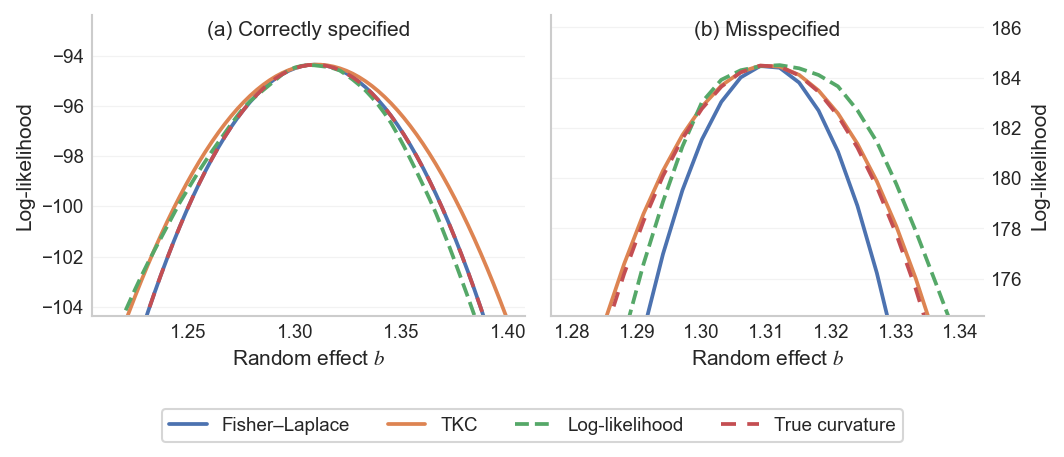

In [13]:
PALETTE = [
    "#4C72B0",  # muted blue
    "#DD8452",  # muted orange
    "#55A868",  # muted green
    "#C44E52",  # muted red
    "#8172B3",  # muted purple
    "#937860",  # muted brown
    ]
fig = plot_vis_comparison_core(
    N=200,
    results_file="vis_results.pkl",
    palette=PALETTE
)
plt.show()
